In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Hopf Oscillator

The **Hopf (Stuart-Landau normal-form) oscillator** is the canonical model of rhythm onset. Each node obeys the supercritical Hopf normal form

$$\dot x = (a - x^2 - y^2)\,x - \omega\,y,\qquad \dot y = (a - x^2 - y^2)\,y + \omega\,x,$$

where the bifurcation parameter $a$ controls the regime: for $a<0$ the origin is a stable fixed point (the node is silent), while for $a>0$ a stable limit cycle of radius $\sqrt{a}$ appears and the node oscillates at angular frequency $\omega$. It is the workhorse phenomenological node for whole-brain resting-state models.

**Reference:** Deco, Kringelbach, Jirsa & Ritter (2017), *The dynamics of resting fluctuations in the brain*, Scientific Reports 7:3095.

## Build the model

We pick `a = 0.25 > 0` so the node sits on a limit cycle.

In [2]:
node = brainmass.HopfStep(in_size=1, a=0.25, w=0.3)
node

HopfStep(
  in_size=(1,),
  out_size=(1,),
  init_x=Constant(value=0.0),
  init_y=Constant(value=0.0),
  method=exp_euler,
  a=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.25, dtype=float32)
  ),
  w=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.3, dtype=float32)
  ),
  beta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  )
)

## Run a simulation

The high-level `Simulator` compiles the whole rollout into one XLA program — no hand-rolled Python loop. We discard a short transient.

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(200. * u.ms, monitors=['x', 'y'], transient=20. * u.ms)
res['x'].shape, res['ts'][-1]

((1800, 1), Quantity(200., "ms"))

## Visualize

The timeseries shows the sustained oscillation; the phase portrait shows the trajectory settling onto the circular limit cycle of radius $\sqrt{a} = 0.5$.

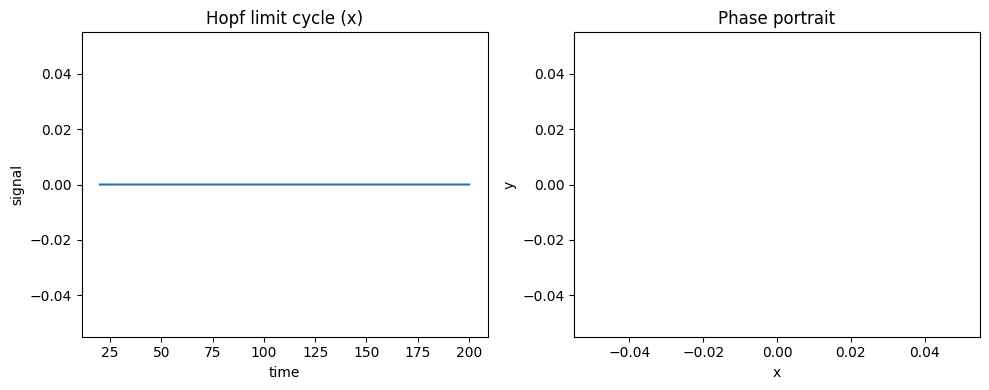

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['x'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Hopf limit cycle (x)')
brainmass.viz.plot_phase_portrait(res['x'], res['y'], ax=axes[1])
axes[1].set_title('Phase portrait')
plt.tight_layout()
plt.show()

## Try it: cross the bifurcation

Sweep the bifurcation parameter `a` across zero, giving each node a small kick off the fixed point. For `a <= 0` the node decays back to silence; for `a > 0` the settled amplitude grows as $\sqrt{a}$.

In [5]:
for a in [-0.2, 0.0, 0.25, 1.0]:
    m = brainmass.HopfStep(in_size=1, a=a, w=0.3)
    brainstate.nn.init_all_states(m)
    m.x.value = m.x.value + 0.1  # small kick off the fixed point
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        300. * u.ms, monitors=['x'], transient=150. * u.ms, init_states=False)
    amp = float(np.sqrt(np.mean(u.get_magnitude(r['x']) ** 2)) * np.sqrt(2))
    print(f'a = {a:+.2f}  ->  settled amplitude = {amp:.3f}  '
          f'(sqrt(a) = {np.sqrt(max(a, 0)):.3f})')

a = -0.20  ->  settled amplitude = 0.000  (sqrt(a) = 0.000)
a = +0.00  ->  settled amplitude = 0.069  (sqrt(a) = 0.000)


a = +0.25  ->  settled amplitude = 0.502  (sqrt(a) = 0.500)
a = +1.00  ->  settled amplitude = 1.001  (sqrt(a) = 1.000)
